#  Data Processing — Bone Marrow Transplant in Children
**Dataset :** `bone-marrow.arff` — 187 patients pédiatriques, 37 attributs  
**Objectif :** Préparer et explorer les données pour analyser les facteurs influençant le succès d'une greffe de moelle osseuse.

---
## 1.  Import des bibliothèques

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import warnings
import re

warnings.filterwarnings('ignore')

# Style graphique
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('✅ Bibliothèques importées avec succès.')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   seaborn : {sns.__version__}')

✅ Bibliothèques importées avec succès.
   pandas  : 3.0.1
   numpy   : 2.0.1
   seaborn : 0.13.2


---
## 2.  Chargement et exploration des données

In [ ]:
# ── Lecture manuelle du fichier ARFF ──────────────────────────────────────────
def load_arff(filepath):
    """Charge un fichier ARFF et retourne un DataFrame pandas."""
    attributes = []
    data_lines = []
    in_data = False

    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('%'):
                continue
            if line.lower().startswith('@attribute'):
                parts = line.split(None, 2)
                attributes.append(parts[1])
            elif line.lower() == '@data':
                in_data = True
            elif in_data:
                data_lines.append(line)

    rows = []
    for line in data_lines:
        values = line.split(',')
        rows.append(values)

    df = pd.DataFrame(rows, columns=attributes)
    # Remplacer '?' par NaN
    df.replace('?', np.nan, inplace=True)
    # Conversion numérique là où c'est possible
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass
    return df


df = load_arff(r'C:\Users\nadah\Documents\GitHub\Coding-Week-GR24\Notebooks\bone-marrow.arff')
print(f'✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')

✅ Dataset chargé : 187 lignes × 37 colonnes


In [ ]:
# Aperçu des premières lignes
df.head()

,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,...,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
0,1,1,22.830137,0,1,0,1,1.0,1.0,0.0,...,1.0,7.20,1.338760,5.38,35.0,19,51,32,999,0
1,1,0,23.342466,0,1,0,-1,-1.0,1.0,0.0,...,1.0,4.50,11.078295,0.41,20.6,16,37,1000000,163,1
2,1,0,26.394521,0,1,0,-1,-1.0,1.0,0.0,...,1.0,7.94,19.013230,0.42,23.4,23,20,1000000,435,1
3,0,0,39.684932,1,1,0,1,2.0,1.0,1.0,...,NaN,4.25,29.481647,0.14,50.0,23,29,19,53,1
4,0,1,33.358904,0,0,0,1,2.0,0.0,1.0,...,1.0,51.85,3.972255,13.05,9.0,14,14,1000000,2043,0


In [ ]:
# Informations générales sur le dataset
print('══════════════════════════════════════════')
print('        INFORMATIONS GÉNÉRALES')
print('══════════════════════════════════════════')
print(f'  Nombre de patients      : {df.shape[0]}')
print(f'  Nombre d\'attributs      : {df.shape[1]}')
print(f'  Types de données        :')
print(df.dtypes.value_counts().to_string())
print()
df.info()

══════════════════════════════════════════
        INFORMATIONS GÉNÉRALES
══════════════════════════════════════════
  Nombre de patients      : 187
  Nombre d'attributs      : 37
  Types de données        :
int64      21
float64    15
str         1

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Recipientgender       187 non-null    int64  
 1   Stemcellsource        187 non-null    int64  
 2   Donorage              187 non-null    float64
 3   Donorage35            187 non-null    int64  
 4   IIIV                  187 non-null    int64  
 5   Gendermatch           187 non-null    int64  
 6   DonorABO              187 non-null    int64  
 7   RecipientABO          186 non-null    float64
 8   RecipientRh           185 non-null    float64
 9   ABOmatch              186 non-null    float64
 10  CMVstatus             171 non-null    

---
## 3.  Identification et suppression des valeurs manquantes

In [ ]:
# Comptage des valeurs manquantes par colonne
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
}).sort_values('Valeurs manquantes', ascending=False)

print('══════════════════════════════════════════════════════')
print('         VALEURS MANQUANTES PAR COLONNE')
print('══════════════════════════════════════════════════════')
print(missing_df[missing_df['Valeurs manquantes'] > 0].to_string())
print(f'\nTotal cellules manquantes : {df.isnull().sum().sum()}')
print(f'Pourcentage global        : {df.isnull().sum().sum() / df.size * 100:.2f}%')

══════════════════════════════════════════════════════
         VALEURS MANQUANTES PAR COLONNE
══════════════════════════════════════════════════════
              Valeurs manquantes  Pourcentage (%)
extcGvHD                      31            16.58
CMVstatus                     16             8.56
RecipientCMV                  14             7.49
CD3dCD34                       5             2.67
CD3dkgx10d8                    5             2.67
RecipientRh                    2             1.07
Rbodymass                      2             1.07
DonorCMV                       2             1.07
RecipientABO                   1             0.53
Alel                           1             0.53
ABOmatch                       1             0.53
Antigen                        1             0.53

Total cellules manquantes : 81
Pourcentage global        : 1.17%


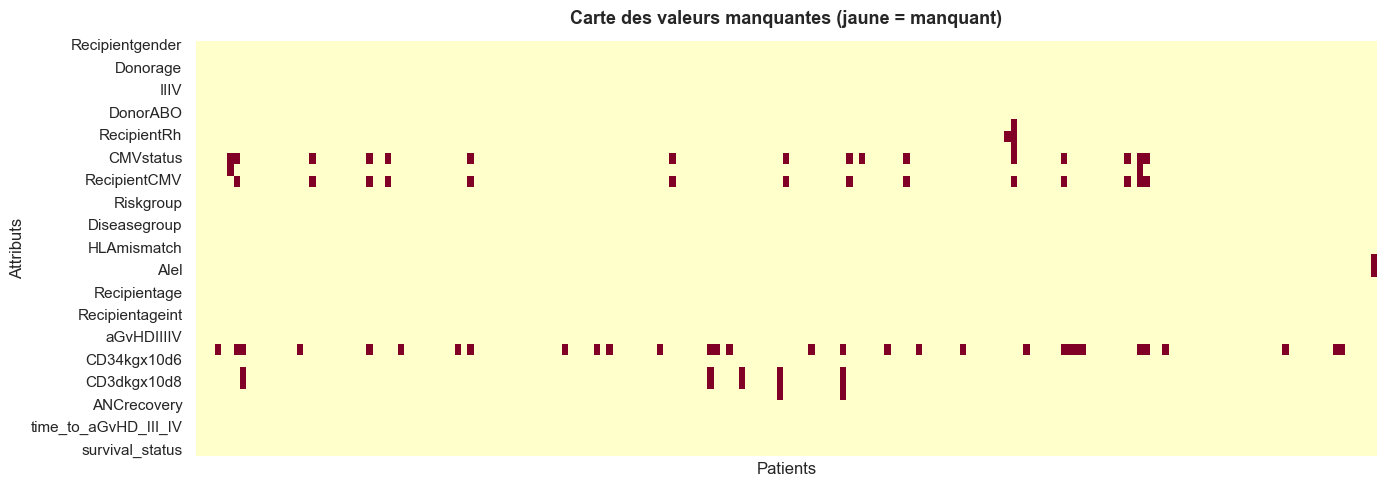

In [ ]:
# Visualisation de la carte des valeurs manquantes
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    df.isnull().T,
    cmap='YlOrRd',
    cbar=False,
    ax=ax,
    xticklabels=False
)
ax.set_title('Carte des valeurs manquantes (jaune = manquant)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Patients')
ax.set_ylabel('Attributs')
plt.tight_layout()
plt.show()

In [ ]:
# ── Suppression des valeurs manquantes ────────────────────────────────────────
# Étape 1 : Supprimer les colonnes avec > 40 % de valeurs manquantes
threshold_col = 0.40
cols_to_drop = missing_pct[missing_pct > threshold_col * 100].index.tolist()
print(f'Colonnes supprimées (> {int(threshold_col*100)}% manquants) : {cols_to_drop}')
df_clean = df.drop(columns=cols_to_drop)

# Étape 2 : Supprimer les lignes restantes avec des valeurs manquantes
rows_before = len(df_clean)
df_clean = df_clean.dropna()
rows_after = len(df_clean)

print(f'\nLignes supprimées avec NaN restants : {rows_before - rows_after}')
print(f'\n✅ Dataset nettoyé : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes')
print(f'   Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}')

Colonnes supprimées (> 40% manquants) : []

Lignes supprimées avec NaN restants : 45

✅ Dataset nettoyé : 142 lignes × 37 colonnes
   Valeurs manquantes restantes : 0


---
## 4.  Analyse des corrélations : Covariance & Écart-type

In [ ]:
# Sélection des colonnes numériques uniquement
numeric_df = df_clean.select_dtypes(include=[np.number])
print(f'Colonnes numériques sélectionnées ({len(numeric_df.columns)}) :')
print(list(numeric_df.columns))

Colonnes numériques sélectionnées (36) :
['Recipientgender', 'Stemcellsource', 'Donorage', 'Donorage35', 'IIIV', 'Gendermatch', 'DonorABO', 'RecipientABO', 'RecipientRh', 'ABOmatch', 'CMVstatus', 'DonorCMV', 'RecipientCMV', 'Riskgroup', 'Txpostrelapse', 'Diseasegroup', 'HLAmatch', 'HLAmismatch', 'Antigen', 'Alel', 'HLAgrI', 'Recipientage', 'Recipientage10', 'Recipientageint', 'Relapse', 'aGvHDIIIIV', 'extcGvHD', 'CD34kgx10d6', 'CD3dCD34', 'CD3dkgx10d8', 'Rbodymass', 'ANCrecovery', 'PLTrecovery', 'time_to_aGvHD_III_IV', 'survival_time', 'survival_status']


In [ ]:
# ── Écart-type ────────────────────────────────────────────────────────────────
std_series = numeric_df.std().sort_values(ascending=False)

print('══════════════════════════════════════════')
print('     ÉCART-TYPE PAR VARIABLE (top 10)')
print('══════════════════════════════════════════')
print(std_series.head(10).round(4).to_string())

══════════════════════════════════════════
     ÉCART-TYPE PAR VARIABLE (top 10)
══════════════════════════════════════════
time_to_aGvHD_III_IV    404548.0670
PLTrecovery             144311.4242
survival_time              816.8153
Rbodymass                   17.9849
CD34kgx10d6                  9.9007
CD3dCD34                     9.7400
Donorage                     8.0077
Recipientage                 5.0430
CD3dkgx10d8                  3.6931
ANCrecovery                  2.8392


In [ ]:
# ── Matrice de covariance ─────────────────────────────────────────────────────
cov_matrix = numeric_df.cov()

print('Matrice de covariance (extrait 6×6) :')
cov_matrix.iloc[:6, :6].round(3)

Matrice de covariance (extrait 6×6) :


,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch
Recipientgender,0.239,0.007,-0.425,-0.032,-0.016,0.066
Stemcellsource,0.007,0.151,0.152,0.019,-0.000,-0.004
Donorage,-0.425,0.152,64.123,3.357,-0.401,0.296
Donorage35,-0.032,0.019,3.357,0.243,-0.004,0.008
IIIV,-0.016,-0.000,-0.401,-0.004,0.239,-0.005
Gendermatch,0.066,-0.004,0.296,0.008,-0.005,0.141


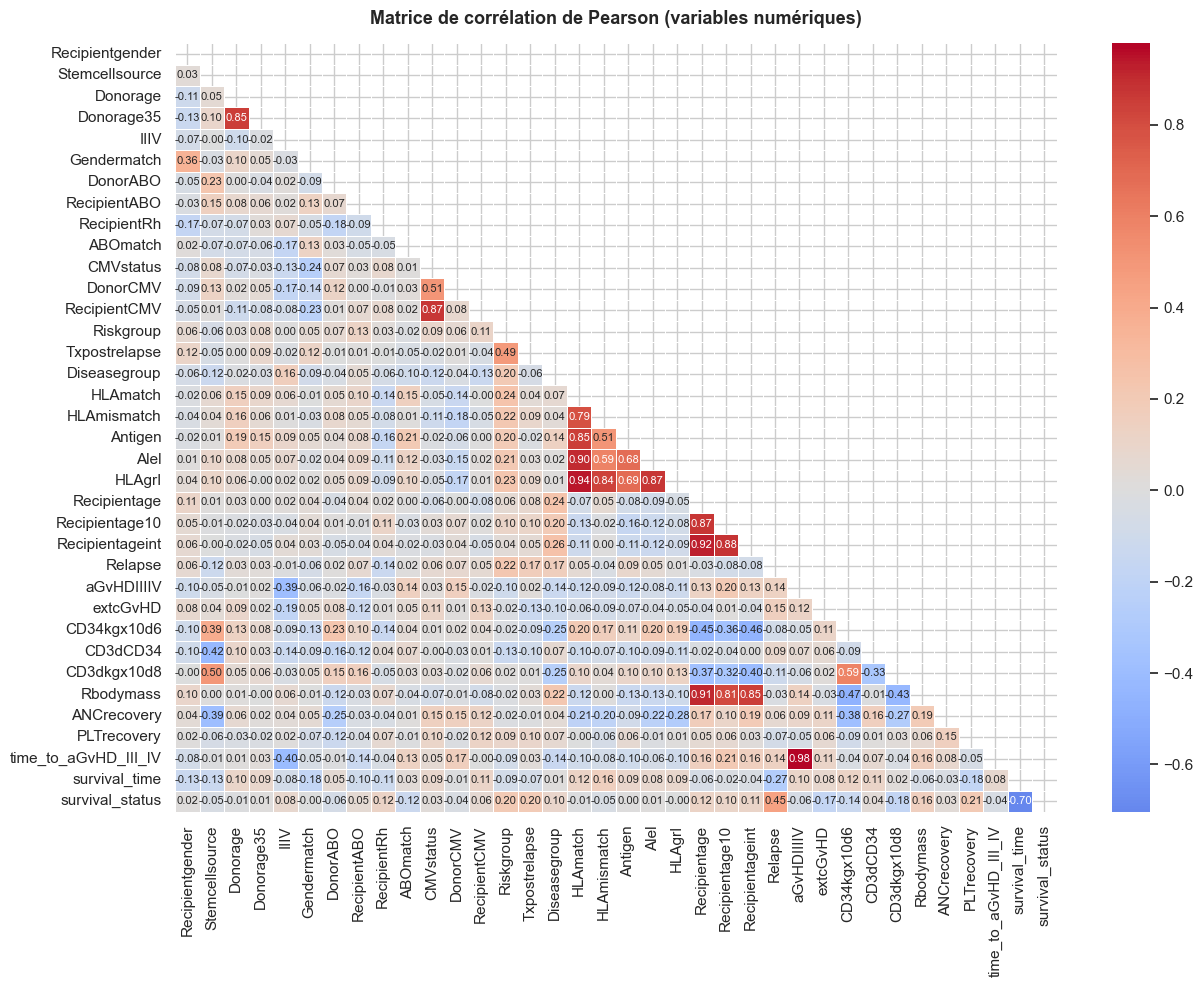

In [ ]:
# ── Matrice de corrélation de Pearson ─────────────────────────────────────────
corr_matrix = numeric_df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # triangle sup masqué
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.4,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Matrice de corrélation de Pearson (variables numériques)', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

In [ ]:
# Top corrélations avec survival_status
if 'survival_status' in corr_matrix.columns:
    top_corr = corr_matrix['survival_status'].drop('survival_status').abs().sort_values(ascending=False)
    print('══════════════════════════════════════════════════════════')
    print('  CORRÉLATIONS LES PLUS FORTES AVEC survival_status')
    print('══════════════════════════════════════════════════════════')
    print(top_corr.head(10).round(4).to_string())

══════════════════════════════════════════════════════════
  CORRÉLATIONS LES PLUS FORTES AVEC survival_status
══════════════════════════════════════════════════════════
survival_time    0.7041
Relapse          0.4514
PLTrecovery      0.2056
Riskgroup        0.1985
Txpostrelapse    0.1951
CD3dkgx10d8      0.1807
extcGvHD         0.1707
Rbodymass        0.1606
CD34kgx10d6      0.1366
ABOmatch         0.1240


---
## 5.  Visualisations

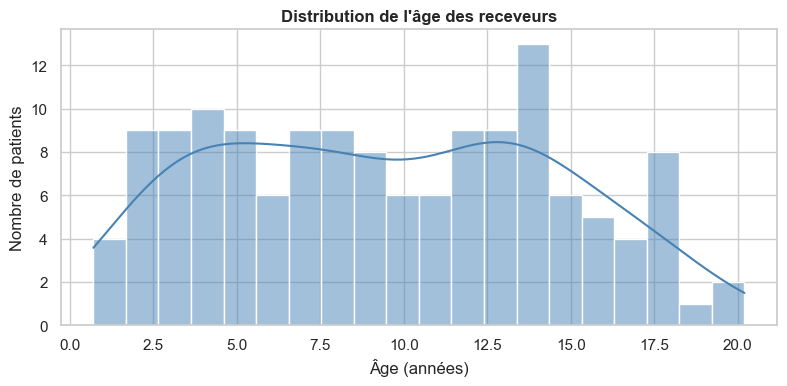

In [ ]:
# ── Distribution de l'âge du receveur ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_clean['Recipientage'], kde=True, color='steelblue', bins=20, ax=ax)
ax.set_title("Distribution de l'âge des receveurs", fontweight='bold')
ax.set_xlabel('Âge (années)')
ax.set_ylabel('Nombre de patients')
plt.tight_layout()
plt.show()

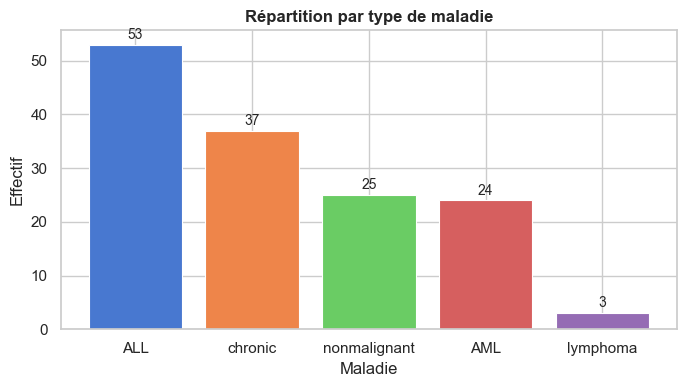

In [ ]:
# ── Répartition de la maladie ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
disease_counts = df_clean['Disease'].value_counts()
colors = sns.color_palette('muted', len(disease_counts))
bars = ax.bar(disease_counts.index, disease_counts.values, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, disease_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
            ha='center', va='bottom', fontsize=10)
ax.set_title('Répartition par type de maladie', fontweight='bold')
ax.set_xlabel('Maladie')
ax.set_ylabel('Effectif')
plt.tight_layout()
plt.show()

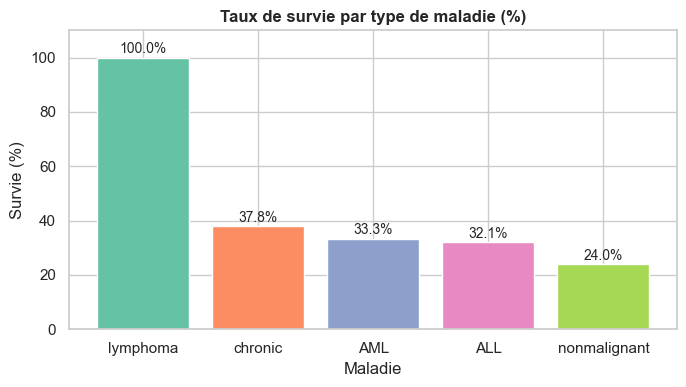

In [ ]:
# ── Taux de survie par maladie ────────────────────────────────────────────────
if 'survival_status' in df_clean.columns:
    df_clean['survival_status'] = pd.to_numeric(df_clean['survival_status'], errors='coerce')
    surv_by_disease = df_clean.groupby('Disease')['survival_status'].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(surv_by_disease.index, surv_by_disease.values * 100,
                  color=sns.color_palette('Set2', len(surv_by_disease)), edgecolor='white')
    for bar, val in zip(bars, surv_by_disease.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.set_title('Taux de survie par type de maladie (%)', fontweight='bold')
    ax.set_xlabel('Maladie')
    ax.set_ylabel('Survie (%)')
    ax.set_ylim(0, 110)
    plt.tight_layout()
    plt.show()

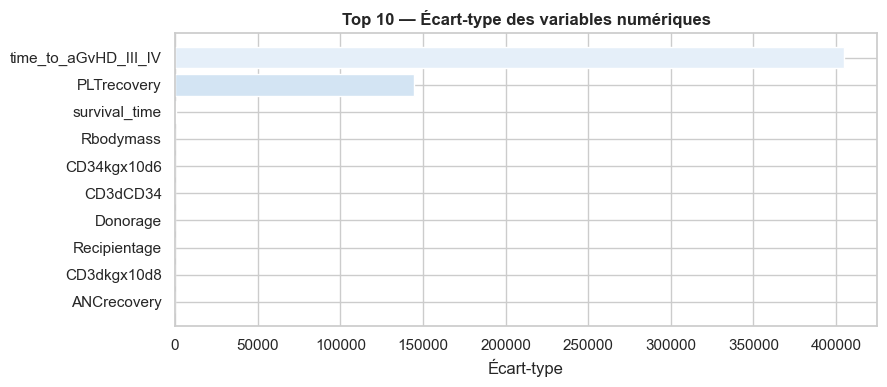

In [ ]:
# ── Écart-type des variables numériques ──────────────────────────────────────
top_std = std_series.head(10)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top_std.index[::-1], top_std.values[::-1],
        color=sns.color_palette('Blues_r', len(top_std)))
ax.set_title('Top 10 — Écart-type des variables numériques', fontweight='bold')
ax.set_xlabel('Écart-type')
plt.tight_layout()
plt.show()

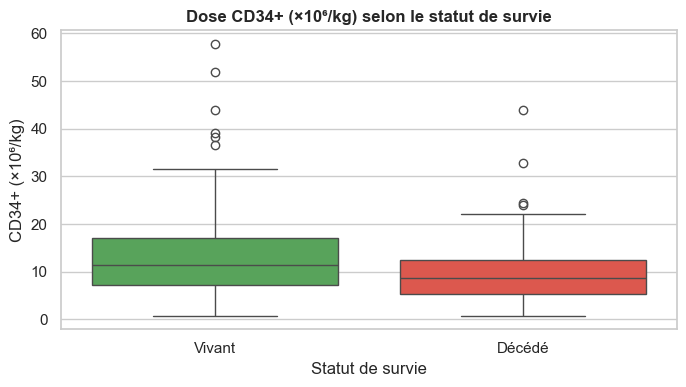

In [ ]:
# ── Boxplot : dose CD34 selon survie ─────────────────────────────────────────
if 'survival_status' in df_clean.columns and 'CD34kgx10d6' in df_clean.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    df_clean['survival_label'] = df_clean['survival_status'].map({1: 'Décédé', 0: 'Vivant'})
    sns.boxplot(data=df_clean, x='survival_label', y='CD34kgx10d6',
                palette={'Vivant': '#4CAF50', 'Décédé': '#F44336'}, ax=ax)
    ax.set_title('Dose CD34+ (×10⁶/kg) selon le statut de survie', fontweight='bold')
    ax.set_xlabel('Statut de survie')
    ax.set_ylabel('CD34+ (×10⁶/kg)')
    plt.tight_layout()
    plt.show()

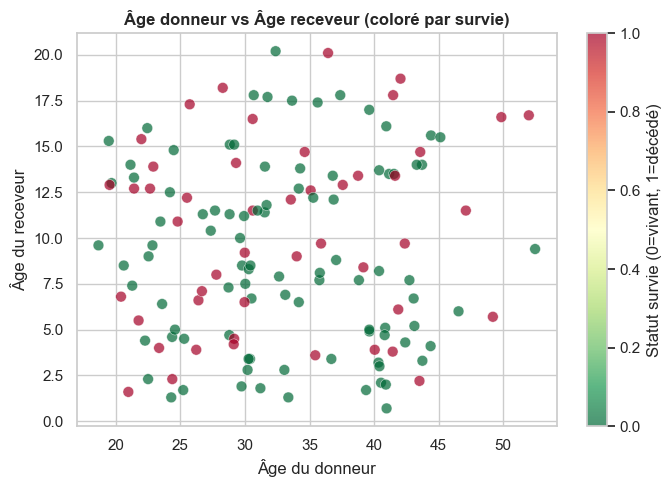

In [ ]:
# ── Scatter : âge donneur vs âge receveur, coloré par survie ─────────────────
if 'survival_status' in df_clean.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    scatter = ax.scatter(
        df_clean['Donorage'], df_clean['Recipientage'],
        c=df_clean['survival_status'], cmap='RdYlGn_r',
        alpha=0.7, edgecolors='white', linewidth=0.4, s=60
    )
    plt.colorbar(scatter, ax=ax, label='Statut survie (0=vivant, 1=décédé)')
    ax.set_title('Âge donneur vs Âge receveur (coloré par survie)', fontweight='bold')
    ax.set_xlabel('Âge du donneur')
    ax.set_ylabel('Âge du receveur')
    plt.tight_layout()
    plt.show()

---
## 6.  Sauvegarde du dataset final

In [ ]:
# Suppression de la colonne label temporaire
if 'survival_label' in df_clean.columns:
    df_clean = df_clean.drop(columns=['survival_label'])

# Sauvegarde CSV
output_path = 'bone_marrow_clean.csv'
df_clean.to_csv(output_path, index=False)

print('══════════════════════════════════════════════════════')
print('              RÉCAPITULATIF FINAL')
print('══════════════════════════════════════════════════════')
print(f'  Fichier sauvegardé       : {output_path}')
print(f'  Taille du dataset initial : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'  Taille du dataset final   : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes')
print(f'  Valeurs manquantes        : {df_clean.isnull().sum().sum()}')
print(f'  Variables numériques      : {len(df_clean.select_dtypes(include=np.number).columns)}')
print(f'  Variables catégorielles   : {len(df_clean.select_dtypes(exclude=np.number).columns)}')
print('\n✅ Dataset propre sauvegardé avec succès !')

══════════════════════════════════════════════════════
              RÉCAPITULATIF FINAL
══════════════════════════════════════════════════════
  Fichier sauvegardé       : bone_marrow_clean.csv
  Taille du dataset initial : 187 lignes × 37 colonnes
  Taille du dataset final   : 142 lignes × 37 colonnes
  Valeurs manquantes        : 0
  Variables numériques      : 36
  Variables catégorielles   : 1

✅ Dataset propre sauvegardé avec succès !
